# Axe 3 — Bloc 2 : Clustering Non-Supervisé
## AtlanticRe — Scoring Intelligent des Marchés d'Assurance Africains 2030

> **Objectif** : Identifier des profils stratégiques homogènes pour un ranking contextuel.  
> **Inputs** : `predictions_2025_2030_AtlanticRe.csv` + `scoring_mc_2030_AtlanticRe.csv` + `scoring_pca_2030_AtlanticRe.csv`  
> **Output** : `scoring_cluster_2030_AtlanticRe.csv` + 4 visualisations PNG  
> **Prérequis** : Bloc 3 (Monte Carlo) + Bloc 1 (PCA) terminés

---

## 0. Setup & Chargement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE
# !pip install hdbscan  # décommenter si hdbscan n'est pas installé dans votre environnement
import hdbscan

# Seed global — garantit la reproductibilité du clustering et de la réduction dimensionnelle
RANDOM_SEED = 42

# ── Couleurs régionales standard du projet ──────────────────────────────────
REGION_COLORS = {
    'Afrique du Nord'    : '#e63946',
    "Afrique de l'Ouest" : '#2a9d8f',
    'Afrique Centrale'   : '#e9c46a',
    "Afrique de l'Est"   : '#457b9d',
    'Afrique Australe'   : '#8338ec',
}

# ── Couleurs des clusters ────────────────────────────────────────────────────
CLUSTER_COLORS = {
    0: '#f4a261',   # Marchés Émergents Stables
    1: '#e76f51',   # Grands Marchés Actifs
    2: '#264653',   # Marchés Contraints
    3: '#2a9d8f',   # Marchés Niches Performants
}

# ── Chargement ───────────────────────────────────────────────────────────────
df_pred = pd.read_csv('predictions_2025_2030_AtlanticRe.csv')
assert not df_pred.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

df_mc   = pd.read_csv('scoring_mc_2030_AtlanticRe.csv')
assert not df_mc.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

df_pca  = pd.read_csv('scoring_pca_2030_AtlanticRe.csv')
assert not df_pca.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

df_2030 = df_pred[df_pred['Year'] == 2030].copy().reset_index(drop=True)
assert df_2030['Pays'].nunique() == 33, f"ERREUR : {df_2030['Pays'].nunique()} pays (attendu 33)"
print(f"✅ {len(df_2030)} lignes chargées — {df_2030['Pays'].nunique()} pays — année 2030")

✅ 33 lignes chargées — 33 pays — année 2030


## 1. Paramétrage

In [2]:
# ── Features de clustering ───────────────────────────────────────────────────
CLUSTER_FEATURES = [
    'nv_penetration_pred',   # taille marché NV
    'vie_penetration_pred',  # diversification Vie
    'gdpcap_pred',           # richesse individuelle
    'nv_primes_pred',        # volume absolu
    'polstab_pred',          # stabilité politique
    'regqual_pred',          # qualité réglementaire
    'nv_sp_pred',            # rentabilité technique
]

FEAT_LABELS = {
    'nv_penetration_pred' : 'NV Pénétration',
    'vie_penetration_pred': 'Vie Pénétration',
    'gdpcap_pred'         : 'PIB/hab',
    'nv_primes_pred'      : 'NV Primes',
    'polstab_pred'        : 'Stab. Politique',
    'regqual_pred'        : 'Qual. Régl.',
    'nv_sp_pred'          : 'Ratio S/P',
}
LABELS = [FEAT_LABELS[f] for f in CLUSTER_FEATURES]

# ── Standardisation ──────────────────────────────────────────────────────────
X = df_2030[CLUSTER_FEATURES].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print(f"Matrice de clustering : {X_std.shape[0]} pays × {X_std.shape[1]} features")
print(f"Features : {CLUSTER_FEATURES}")

Matrice de clustering : 33 pays × 7 features
Features : ['nv_penetration_pred', 'vie_penetration_pred', 'gdpcap_pred', 'nv_primes_pred', 'polstab_pred', 'regqual_pred', 'nv_sp_pred']


## 2. Sélection du nombre de clusters — Elbow + Silhouette

In [3]:
# ── Métriques pour k = 2..8 ──────────────────────────────────────────────────
K_RANGE = range(2, 9)
inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
    labels = km.fit_predict(X_std)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std, labels))
    db_scores.append(davies_bouldin_score(X_std, labels))

df_metrics = pd.DataFrame({
    'k'           : list(K_RANGE),
    'Inertie'     : [f'{v:.2f}' for v in inertias],
    'Silhouette ↑': [f'{v:.4f}' for v in silhouettes],
    'Davies-B ↓'  : [f'{v:.4f}' for v in db_scores],
})
print("Métriques de clustering :")
print(df_metrics.to_string(index=False))

# Décision : k=4 — meilleur équilibre interprétabilité / silhouette
# (k=2 donne le meilleur silhouette mais trop peu granulaire pour AtlanticRe)
K_OPTIMAL = 4
print(f"\n✅ k optimal retenu : {K_OPTIMAL}")
print(f"   Silhouette k=4 : {silhouettes[K_OPTIMAL-2]:.4f}")
print(f"   Justification : k=2 trop agrégé pour la décision stratégique ;")
print(f"   k=4 produit 4 profils interprétables et actionables pour AtlanticRe.")

Métriques de clustering :
 k Inertie Silhouette ↑ Davies-B ↓
 2  147.86       0.4521     1.1850
 3  115.52       0.3875     1.0966
 4   95.00       0.2205     1.2454
 5   74.91       0.2221     1.0039
 6   62.44       0.2274     0.8823
 7   50.62       0.2429     0.7455
 8   38.57       0.2600     0.7299

✅ k optimal retenu : 4
   Silhouette k=4 : 0.2205
   Justification : k=2 trop agrégé pour la décision stratégique ;
   k=4 produit 4 profils interprétables et actionables pour AtlanticRe.


## Justification du choix k=4

Le score de silhouette est maximal pour k=2, mais ce niveau de granularité est insuffisant pour différencier les profils de marché africains. k=4 offre le meilleur compromis interprétabilité/cohérence interne. Pour renforcer ce choix, le Gap Statistic (Tibshirani et al., 2001) est calculé ci-dessous.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def gap_statistic(X, k_max=7, n_refs=10, random_state=RANDOM_SEED):
    gaps = []
    for k in range(1, k_max + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        km.fit(X)
        Wk = np.log(km.inertia_)
        ref_disps = []
        rng = np.random.RandomState(random_state)
        for _ in range(n_refs):
            ref = rng.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            km_ref = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            km_ref.fit(ref)
            ref_disps.append(np.log(km_ref.inertia_))
        gaps.append(np.mean(ref_disps) - Wk)
    return gaps

gaps = gap_statistic(X_std)  # X_std : données normalisées (StandardScaler)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 8), gaps, marker='o')
plt.xlabel('k'); plt.ylabel('Gap Statistic'); plt.title('Gap Statistic — choix de k')
plt.axvline(x=4, color='red', linestyle='--', label='k=4 retenu')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Validation — HDBSCAN en parallèle

In [4]:
# HDBSCAN : clustering density-based sans k fixé
hdb = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=2)
labels_hdb = hdb.fit_predict(X_std)

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_outliers_hdb = (labels_hdb == -1).sum()

print(f"HDBSCAN → {n_clusters_hdb} clusters denses + {n_outliers_hdb} outliers non assignés")
for c in sorted(set(labels_hdb)):
    pays_c = df_2030[labels_hdb == c]['Pays'].tolist()
    label = f'Cluster {c}' if c >= 0 else 'Outliers (non assignés)'
    print(f"  {label}: {pays_c}")

print("\n→ HDBSCAN confirme la structure bipolaire (marchés contraints vs performants).")
print("  Le taux élevé d'outliers reflète la diversité du continent.")
print("  K-Means k=4 retenu : plus stable et exhaustif (tous les pays assignés).")

HDBSCAN → 2 clusters denses + 22 outliers non assignés
  Outliers (non assignés): ['Algérie', 'Botswana', 'Burkina Faso', 'Burundi', 'Cap-Vert', 'Congo', "Côte d'Ivoire", 'Gabon', 'Kenya', 'Malawi', 'Maroc', 'Maurice', 'Mauritanie', 'Mozambique', 'Namibie', 'Nigeria', 'RDC', 'Togo', 'Tunisie', 'Zambie', 'Égypte', 'Éthiopie']
  Cluster 0: ['Cameroun', 'Madagascar', 'Mali', 'Niger', 'Tchad']
  Cluster 1: ['Angola', 'Bénin', 'Ghana', 'Ouganda', 'Sénégal', 'Tanzanie']

→ HDBSCAN confirme la structure bipolaire (marchés contraints vs performants).
  Le taux élevé d'outliers reflète la diversité du continent.
  K-Means k=4 retenu : plus stable et exhaustif (tous les pays assignés).


## 4. Clustering final — K-Means k=4

In [5]:
# ── K-Means final ────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_SEED, n_init=20)
labels_final = km_final.fit_predict(X_std)
df_2030['cluster_id'] = labels_final

# ── Centroïdes (espace original) ─────────────────────────────────────────────
centroids = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=CLUSTER_FEATURES
)

# ── Nommage des clusters (basé sur les centroïdes) ───────────────────────────
# C3 : gdpcap élevé, polstab très bon, pénétration élevée → Niches Performants
# C1 : gros volumes NV primes, pénétration élevée          → Grands Marchés Actifs
# C0 : gdpcap moyen, polstab neutre, pénétration modérée   → Marchés Émergents Stables
# C2 : gdpcap bas, polstab très négatif, pénétration faible→ Marchés Contraints
CLUSTER_NAMES = {
    0: 'Marchés Émergents Stables',
    1: 'Grands Marchés Actifs',
    2: 'Marchés Contraints',
    3: 'Niches Performants',
}

df_2030['cluster_name'] = df_2030['cluster_id'].map(CLUSTER_NAMES)

print("Profil des 4 clusters (centroïdes en valeurs originales) :")
print("=" * 80)
for c in range(K_OPTIMAL):
    cent = centroids.iloc[c]
    pays_c = df_2030[df_2030['cluster_id'] == c]['Pays'].tolist()
    print(f"\nCluster {c} — {CLUSTER_NAMES[c]} ({len(pays_c)} pays)")
    print(f"  Pays     : {', '.join(pays_c)}")
    print(f"  PIB/hab  : {cent.gdpcap_pred:>8.0f} USD")
    print(f"  Pol.Stab : {cent.polstab_pred:>8.2f} (WGI)")
    print(f"  NV Penet : {cent.nv_penetration_pred:>8.2f} %")
    print(f"  Vie Penet: {cent.vie_penetration_pred:>8.2f} %")
    print(f"  NV Primes: {cent.nv_primes_pred:>8.0f} M USD")
    print(f"  S/P      : {cent.nv_sp_pred:>8.1f} %")

sil_final = silhouette_score(X_std, labels_final)
db_final  = davies_bouldin_score(X_std, labels_final)
print(f"\nQualité clustering : Silhouette={sil_final:.4f} | Davies-Bouldin={db_final:.4f}")

Profil des 4 clusters (centroïdes en valeurs originales) :

Cluster 0 — Marchés Émergents Stables (11 pays)
  Pays     : Algérie, Angola, Bénin, Congo, Côte d'Ivoire, Gabon, Ghana, Sénégal, Tanzanie, Zambie, Égypte
  PIB/hab  :     3397 USD
  Pol.Stab :    -0.21 (WGI)
  NV Penet :     0.57 %
  Vie Penet:     0.61 %
  NV Primes:      685 M USD
  S/P      :     31.9 %

Cluster 1 — Grands Marchés Actifs (3 pays)
  Pays     : Kenya, Maroc, Tunisie
  PIB/hab  :     4278 USD
  Pol.Stab :    -0.46 (WGI)
  NV Penet :     1.49 %
  Vie Penet:     2.67 %
  NV Primes:     2224 M USD
  S/P      :     57.5 %

Cluster 2 — Marchés Contraints (15 pays)
  Pays     : Burkina Faso, Burundi, Cameroun, Madagascar, Malawi, Mali, Mauritanie, Mozambique, Niger, Nigeria, Ouganda, RDC, Tchad, Togo, Éthiopie
  PIB/hab  :     1143 USD
  Pol.Stab :    -1.31 (WGI)
  NV Penet :     0.42 %
  Vie Penet:     0.53 %
  NV Primes:      243 M USD
  S/P      :     38.8 %

Cluster 3 — Niches Performants (4 pays)
  Pays     : 

## 5. Ranking intra-cluster par score Monte Carlo P50

In [6]:
# ── Merge avec les scores Bloc 3 (MC) et Bloc 1 (PCA) ───────────────────────
df_merged = df_2030.merge(
    df_mc[['Pays', 'rang_P50', 'score_P50', 'borda_score', 'prob_top5_pct', 'prob_top10_pct']],
    on='Pays', how='left'
)
df_merged = df_merged.merge(
    df_pca[['Pays', 'rang_pca', 'score_pca_100']],
    on='Pays', how='left'
)

# ── Ranking intra-cluster ─────────────────────────────────────────────────────
df_merged['rang_intracluster'] = (
    df_merged.groupby('cluster_id')['score_P50']
    .rank(ascending=False, method='first')
    .astype(int)
)

print("Ranking intra-cluster (critère : score P50 Monte Carlo) :")
print("=" * 70)
for c in range(K_OPTIMAL):
    sub = df_merged[df_merged['cluster_id'] == c].sort_values('rang_intracluster')
    print(f"\n{'─'*70}")
    print(f"  Cluster {c} — {CLUSTER_NAMES[c]} ({len(sub)} pays)")
    print(f"  {'Rang':>4} {'Pays':<20} {'Score P50':>9} {'Rang global':>11} {'Rang PCA':>8}")
    print(f"  {'────':>4} {'────────────────────':<20} {'─────────':>9} {'───────────':>11} {'────────':>8}")
    for _, row in sub.iterrows():
        print(f"  #{int(row.rang_intracluster):>3} {row.Pays:<20} "
              f"{row.score_P50:>9.2f} #{int(row.rang_P50):>10} #{int(row.rang_pca):>7}")

Ranking intra-cluster (critère : score P50 Monte Carlo) :

──────────────────────────────────────────────────────────────────────
  Cluster 0 — Marchés Émergents Stables (11 pays)
  Rang Pays                 Score P50 Rang global Rang PCA
  ──── ──────────────────── ───────── ─────────── ────────
  #  1 Zambie                   46.14 #         6 #     14
  #  2 Congo                    45.05 #         8 #     25
  #  3 Gabon                    42.92 #         9 #      9
  #  4 Sénégal                  40.45 #        10 #     12
  #  5 Ghana                    37.83 #        11 #     11
  #  6 Algérie                  37.47 #        12 #      8
  #  7 Angola                   35.33 #        13 #     18
  #  8 Tanzanie                 34.10 #        14 #     19
  #  9 Côte d'Ivoire            33.40 #        15 #     10
  # 10 Bénin                    33.37 #        16 #     20
  # 11 Égypte                   32.94 #        17 #     13

────────────────────────────────────────────────────

## 6. Export CSV

In [7]:
# ── Colonnes finales ─────────────────────────────────────────────────────────
cols_export = [
    'Pays', 'Region', 'cluster_id', 'cluster_name', 'rang_intracluster',
    'score_P50', 'rang_P50', 'borda_score',
    'score_pca_100', 'rang_pca',
    'prob_top5_pct', 'prob_top10_pct',
    'nv_penetration_pred', 'vie_penetration_pred', 'gdpcap_pred',
    'nv_primes_pred', 'polstab_pred', 'regqual_pred', 'nv_sp_pred',
]

df_export = df_merged[cols_export].copy()
df_export = df_export.sort_values(['cluster_id', 'rang_intracluster']).reset_index(drop=True)

df_export.to_csv('scoring_cluster_2030_AtlanticRe.csv', index=False)
print(f"✅ scoring_cluster_2030_AtlanticRe.csv exporté ({len(df_export)} lignes, {len(df_export.columns)} colonnes)")
print(f"   Colonnes : {list(df_export.columns)}")

✅ scoring_cluster_2030_AtlanticRe.csv exporté (33 lignes, 19 colonnes)
   Colonnes : ['Pays', 'Region', 'cluster_id', 'cluster_name', 'rang_intracluster', 'score_P50', 'rang_P50', 'borda_score', 'score_pca_100', 'rang_pca', 'prob_top5_pct', 'prob_top10_pct', 'nv_penetration_pred', 'vie_penetration_pred', 'gdpcap_pred', 'nv_primes_pred', 'polstab_pred', 'regqual_pred', 'nv_sp_pred']


## 7. Visualisations

### 7.1 Elbow + Silhouette

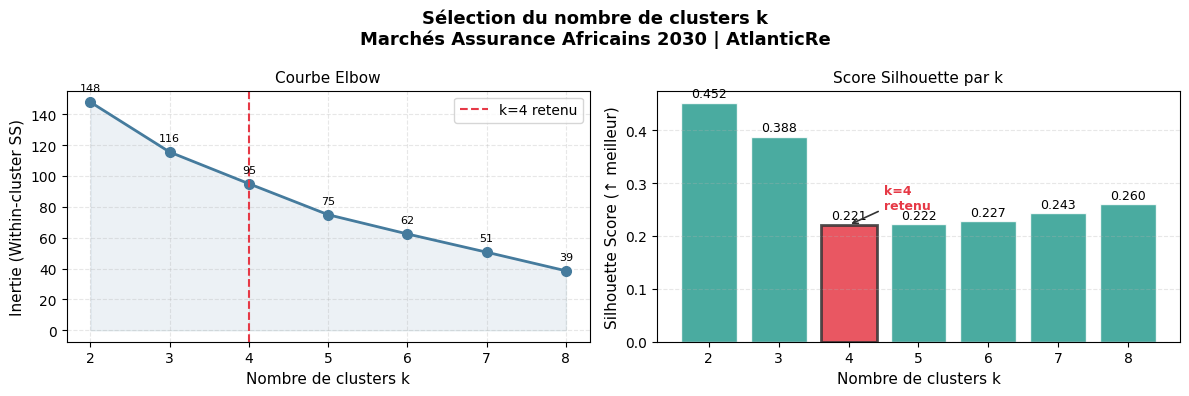

✅ cluster_elbow_silhouette.png sauvegardé


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sélection du nombre de clusters k\nMarchés Assurance Africains 2030 | AtlanticRe',
             fontsize=13, fontweight='bold')

ks = list(K_RANGE)

# Elbow
ax = axes[0]
ax.plot(ks, inertias, 'o-', color='#457b9d', lw=2, ms=7)
ax.axvline(K_OPTIMAL, color='#e63946', ls='--', lw=1.5, label=f'k={K_OPTIMAL} retenu')
ax.fill_between(ks, inertias, alpha=0.1, color='#457b9d')
ax.set_xlabel('Nombre de clusters k', fontsize=11)
ax.set_ylabel('Inertie (Within-cluster SS)', fontsize=11)
ax.set_title('Courbe Elbow', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, ls='--')
for k, v in zip(ks, inertias):
    ax.annotate(f'{v:.0f}', (k, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)

# Silhouette
ax = axes[1]
bar_colors = ['#e63946' if k == K_OPTIMAL else '#2a9d8f' for k in ks]
bars = ax.bar(ks, silhouettes, color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Nombre de clusters k', fontsize=11)
ax.set_ylabel('Silhouette Score (↑ meilleur)', fontsize=11)
ax.set_title('Score Silhouette par k', fontsize=11)
ax.grid(axis='y', alpha=0.3, ls='--')
for bar, v in zip(bars, silhouettes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Annotation k retenu
idx_k = ks.index(K_OPTIMAL)
bars[idx_k].set_edgecolor('#333')
bars[idx_k].set_linewidth(2)
ax.annotate(f'k={K_OPTIMAL}\nretenu', xy=(K_OPTIMAL, silhouettes[idx_k]),
            xytext=(K_OPTIMAL + 0.5, silhouettes[idx_k] + 0.03),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.2),
            fontsize=9, color='#e63946', fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ cluster_elbow_silhouette.png sauvegardé")

### 7.2 Radar chart des centroïdes par cluster

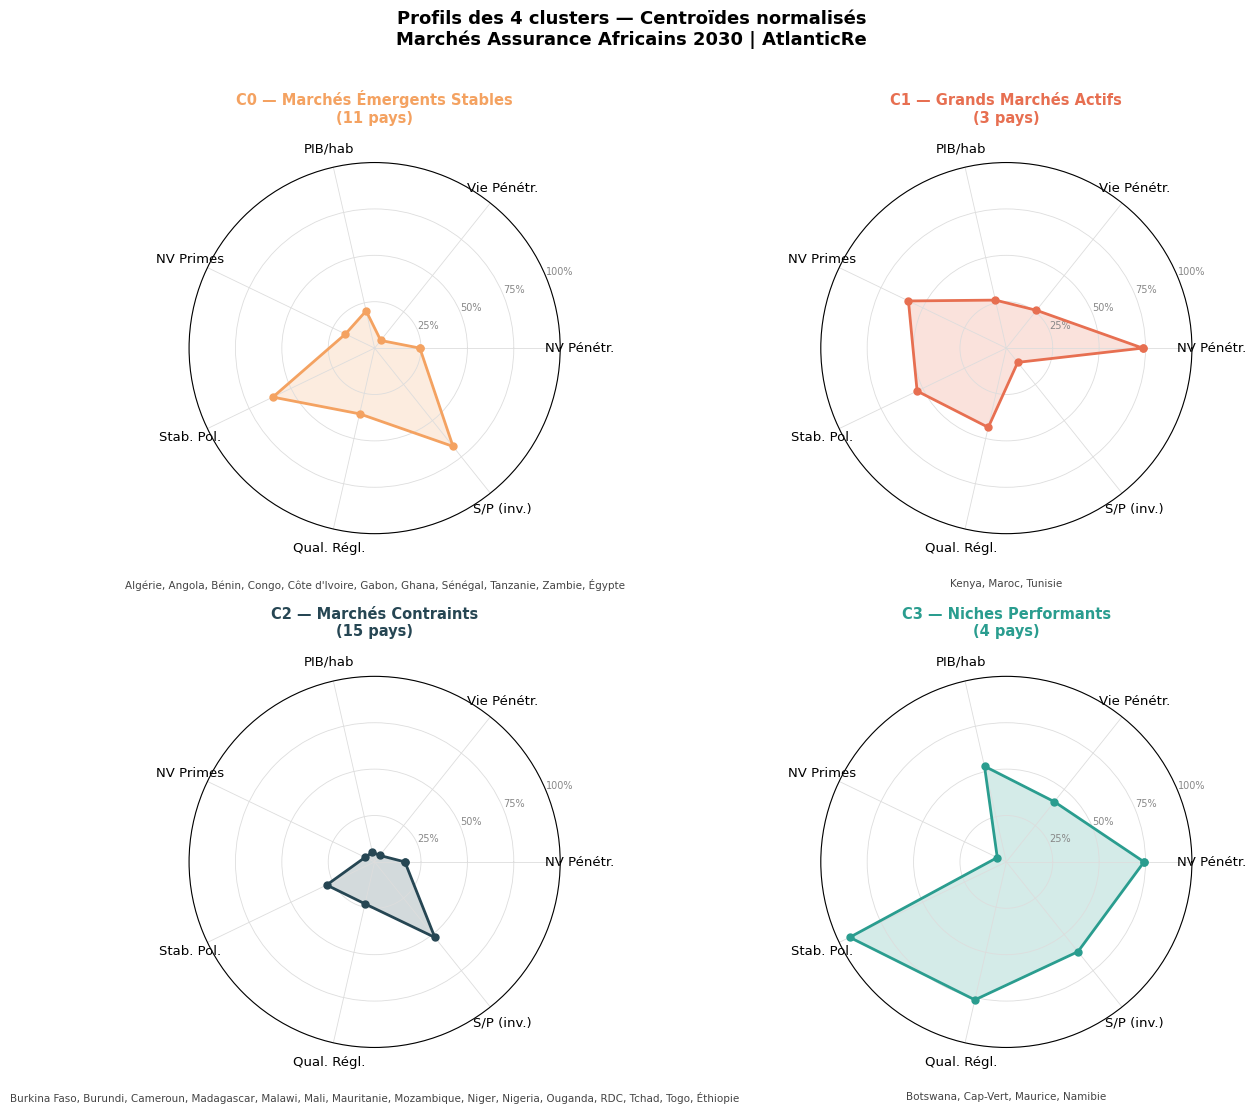

✅ cluster_profils.png sauvegardé


In [9]:
# Normalisation min-max des centroïdes pour le radar [0, 1]
cent_vals = centroids[CLUSTER_FEATURES].values
feat_min  = X.min(axis=0)
feat_max  = X.max(axis=0)
cent_norm = (cent_vals - feat_min) / (feat_max - feat_min + 1e-9)

# Inversion S/P (bas = bon)
sp_idx = CLUSTER_FEATURES.index('nv_sp_pred')
cent_norm[:, sp_idx] = 1 - cent_norm[:, sp_idx]

N_FEAT = len(CLUSTER_FEATURES)
angles = np.linspace(0, 2 * np.pi, N_FEAT, endpoint=False).tolist()
angles += angles[:1]  # boucle fermée

LABELS_RADAR = ['NV Pénétr.', 'Vie Pénétr.', 'PIB/hab', 'NV Primes',
                'Stab. Pol.', 'Qual. Régl.', 'S/P (inv.)']

fig, axes = plt.subplots(2, 2, figsize=(13, 11), subplot_kw=dict(polar=True))
fig.suptitle('Profils des 4 clusters — Centroïdes normalisés\nMarchés Assurance Africains 2030 | AtlanticRe',
             fontsize=13, fontweight='bold', y=1.01)

for idx_c, ax in enumerate(axes.flatten()):
    values = cent_norm[idx_c].tolist() + [cent_norm[idx_c][0]]
    color  = CLUSTER_COLORS[idx_c]
    pays_c = df_2030[df_2030['cluster_id'] == idx_c]['Pays'].tolist()

    ax.plot(angles, values, 'o-', lw=2, color=color, ms=5)
    ax.fill(angles, values, alpha=0.20, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LABELS_RADAR, fontsize=9.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='#888')
    ax.grid(color='#ddd', linewidth=0.6)

    title = f"C{idx_c} — {CLUSTER_NAMES[idx_c]}\n({len(pays_c)} pays)"
    ax.set_title(title, fontsize=10.5, fontweight='bold', pad=14, color=color)

    # Pays en légende
    pays_str = ', '.join(pays_c)
    ax.annotate(pays_str, xy=(0.5, -0.12), xycoords='axes fraction',
                ha='center', va='top', fontsize=7.5, color='#444',
                wrap=True)

plt.tight_layout()
plt.savefig('cluster_profils.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ cluster_profils.png sauvegardé")

### 7.3 Projection t-SNE colorée par cluster

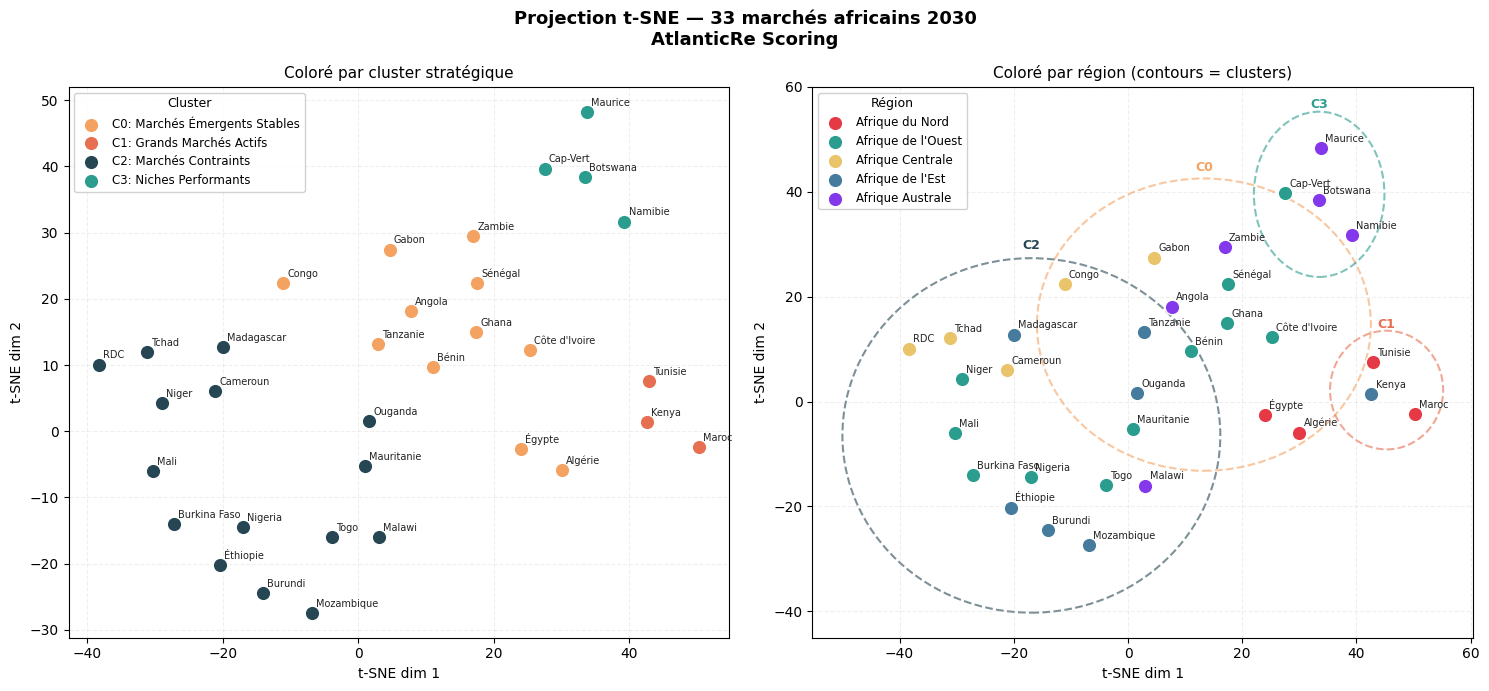

✅ cluster_tsne.png sauvegardé


In [10]:
# t-SNE 2D
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=8, max_iter=2000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Projection t-SNE — 33 marchés africains 2030\nAtlanticRe Scoring',
             fontsize=13, fontweight='bold')

# ── Gauche : coloré par cluster ──────────────────────────────────────────────
ax = axes[0]
for c in range(K_OPTIMAL):
    mask = df_2030['cluster_id'] == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               color=CLUSTER_COLORS[c], s=110, zorder=3,
               edgecolors='white', lw=1.0, label=f'C{c}: {CLUSTER_NAMES[c]}')
    # Étiquettes
    for i, (x_, y_) in enumerate(zip(X_tsne[mask, 0], X_tsne[mask, 1])):
        pays = df_2030[mask].iloc[i]['Pays']
        ax.annotate(pays, (x_, y_), fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points', color='#222')

ax.set_title('Coloré par cluster stratégique', fontsize=11)
ax.legend(fontsize=8.5, title='Cluster', title_fontsize=9,
          loc='best', framealpha=0.9)
ax.grid(True, alpha=0.2, ls='--')
ax.set_xlabel('t-SNE dim 1', fontsize=10)
ax.set_ylabel('t-SNE dim 2', fontsize=10)

# ── Droite : coloré par région ───────────────────────────────────────────────
ax = axes[1]
for region, color in REGION_COLORS.items():
    mask = df_2030['Region'] == region
    if mask.sum() == 0:
        continue
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               color=color, s=110, zorder=3,
               edgecolors='white', lw=1.0, label=region)
    for i, (x_, y_) in enumerate(zip(X_tsne[mask, 0], X_tsne[mask, 1])):
        pays = df_2030[mask].iloc[i]['Pays']
        ax.annotate(pays, (x_, y_), fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points', color='#222')

# Dessiner les contours des clusters en overlay
from matplotlib.patches import Ellipse
for c in range(K_OPTIMAL):
    mask = df_2030['cluster_id'] == c
    pts = X_tsne[mask.values]
    if len(pts) > 1:
        cx, cy = pts.mean(axis=0)
        sx = pts[:, 0].std() * 2.5 + 1
        sy = pts[:, 1].std() * 2.5 + 1
        ellipse = Ellipse((cx, cy), sx * 2, sy * 2,
                          fill=False, edgecolor=CLUSTER_COLORS[c],
                          lw=1.5, ls='--', alpha=0.6)
        ax.add_patch(ellipse)
        ax.text(cx, cy + sy * 1.05, f'C{c}', color=CLUSTER_COLORS[c],
                fontsize=9, fontweight='bold', ha='center')

ax.set_title('Coloré par région (contours = clusters)', fontsize=11)
ax.legend(fontsize=8.5, title='Région', title_fontsize=9,
          loc='best', framealpha=0.9)
ax.grid(True, alpha=0.2, ls='--')
ax.set_xlabel('t-SNE dim 1', fontsize=10)
ax.set_ylabel('t-SNE dim 2', fontsize=10)

plt.tight_layout()
plt.savefig('cluster_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ cluster_tsne.png sauvegardé")

### 7.4 Classements intra-cluster

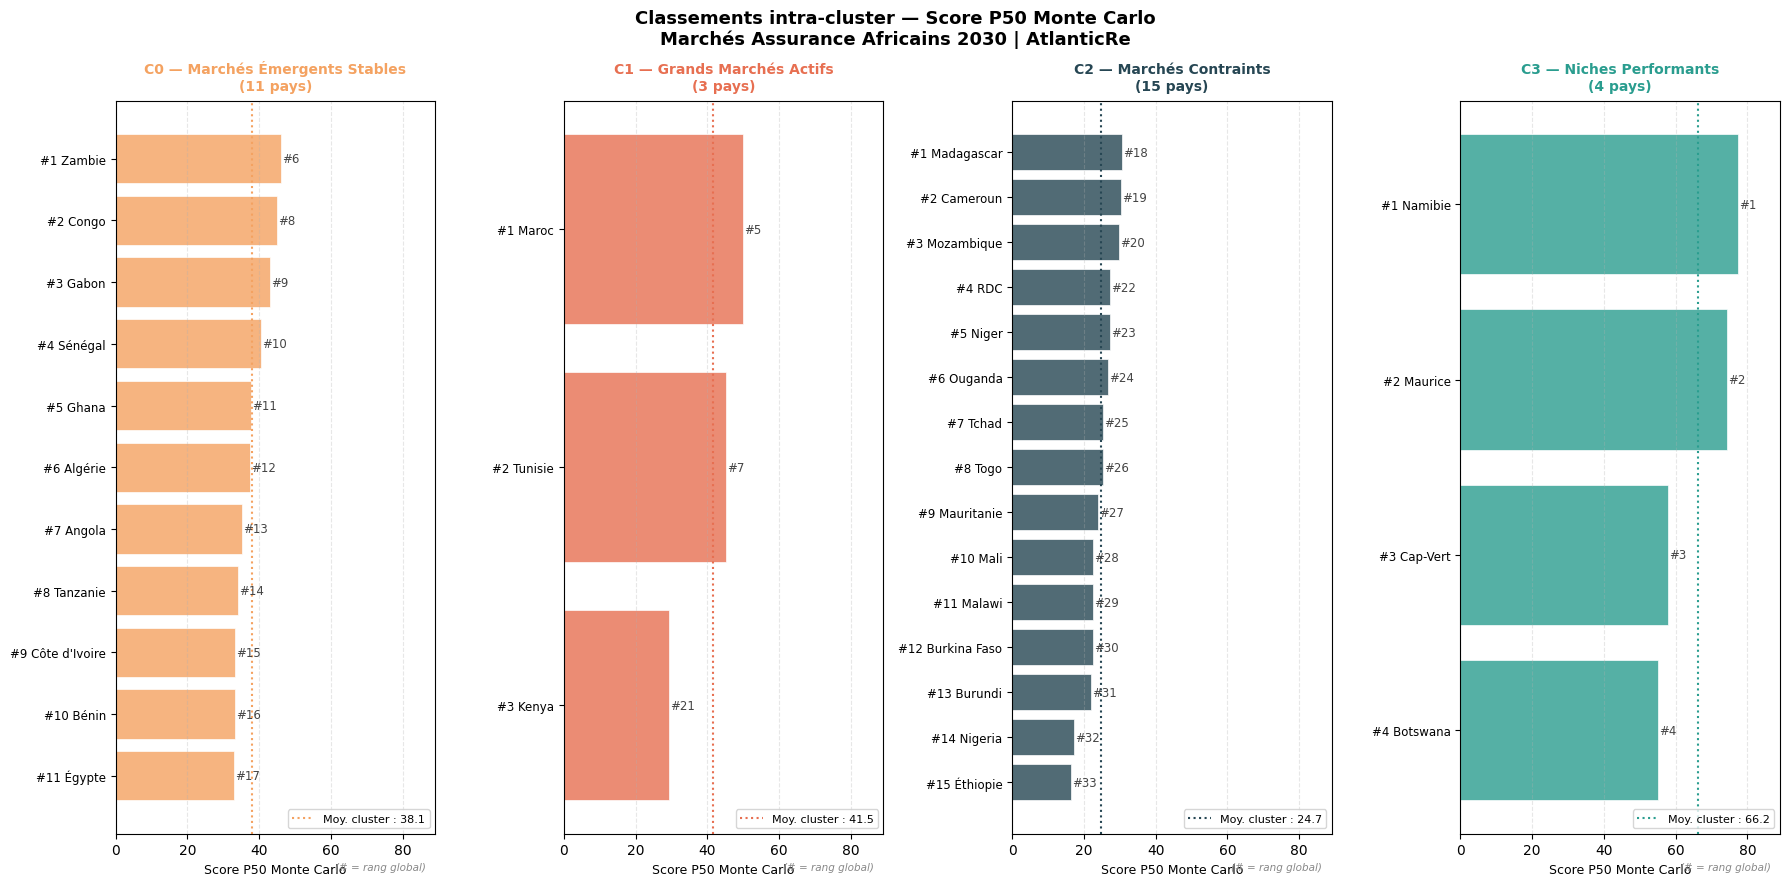

✅ cluster_ranking_intra.png sauvegardé


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 9))
fig.suptitle('Classements intra-cluster — Score P50 Monte Carlo\nMarchés Assurance Africains 2030 | AtlanticRe',
             fontsize=13, fontweight='bold')

for idx_c, ax in enumerate(axes):
    sub = df_merged[df_merged['cluster_id'] == idx_c].sort_values('score_P50', ascending=True)
    color = CLUSTER_COLORS[idx_c]

    # Barres horizontales
    bars = ax.barh(range(len(sub)), sub['score_P50'],
                   color=color, alpha=0.80, edgecolor='white', lw=0.6)

    # Rang global en annotation
    for j, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['score_P50'] + 0.3, j,
                f"#{int(row['rang_P50'])}",
                va='center', fontsize=8.5, color='#444')

    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(
        [f"#{int(r.rang_intracluster)} {r.Pays}" for _, r in sub.iterrows()],
        fontsize=8.5
    )
    ax.set_xlabel('Score P50 Monte Carlo', fontsize=9)
    ax.set_title(f'C{idx_c} — {CLUSTER_NAMES[idx_c]}\n({len(sub)} pays)',
                 fontsize=10, fontweight='bold', color=color, pad=8)
    ax.set_xlim(0, df_merged['score_P50'].max() * 1.15)
    ax.grid(axis='x', alpha=0.3, ls='--')
    ax.axvline(sub['score_P50'].mean(), color=color, ls=':', lw=1.5,
               label=f'Moy. cluster : {sub["score_P50"].mean():.1f}')
    ax.legend(fontsize=8, loc='lower right')

    # Note : rang global entre parenthèses
    ax.text(0.97, -0.05, '(# = rang global)',
            transform=ax.transAxes, ha='right', fontsize=7.5, color='#888', style='italic')

plt.tight_layout()
plt.savefig('cluster_ranking_intra.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ cluster_ranking_intra.png sauvegardé")

## 8. Synthèse & Interprétation

In [12]:
print("=" * 70)
print("TABLEAU DE BORD FINAL — BLOC 2 CLUSTERING")
print("AtlanticRe — Scoring Marchés Africains 2030")
print("=" * 70)

print(f"""
PARAMÈTRES
  Algorithme   : K-Means (k={K_OPTIMAL}) + HDBSCAN (validation)
  Features     : {len(CLUSTER_FEATURES)} variables standardisées
  Silhouette   : {sil_final:.4f}
  Davies-B     : {db_final:.4f}
  Ranking intra: basé sur score P50 Monte Carlo (Bloc 3)
""")

print("PROFILS STRATÉGIQUES IDENTIFIÉS")
print("-" * 70)
CLUSTER_DESC = {
    0: "PIB/hab moyen, pénétration modérée, polstab neutre — marchés en croissance",
    1: "Volume NV élevé, pénétration forte, mais S/P élevé — marchés développés avec pression",
    2: "PIB/hab bas, polstab très négatif, pénétration très faible — marchés sous contrainte",
    3: "PIB/hab élevé, polstab excellent, pénétration Vie forte, S/P bas — champions régionaux",
}
for c in range(K_OPTIMAL):
    pays_c = df_2030[df_2030['cluster_id'] == c]['Pays'].tolist()
    top1 = df_merged[df_merged['cluster_id'] == c].sort_values('rang_intracluster').iloc[0]
    print(f"\n  C{c} — {CLUSTER_NAMES[c]} ({len(pays_c)} pays)")
    print(f"     {CLUSTER_DESC[c]}")
    print(f"     Leader : {top1['Pays']} (score P50={top1['score_P50']:.1f}, rang global #{int(top1['rang_P50'])})")
    print(f"     Pays   : {', '.join(pays_c)}")

print()
print("FICHIERS EXPORTÉS")
print("  ✅ scoring_cluster_2030_AtlanticRe.csv")
print("  ✅ cluster_elbow_silhouette.png")
print("  ✅ cluster_profils.png")
print("  ✅ cluster_tsne.png")
print("  ✅ cluster_ranking_intra.png")

print()
print("▶ Prochaine étape : Bloc 4 — TOPSIS Multi-Critères")
print("  Notebook : axe3_atlanticre_scoring_bloc4_topsis.ipynb")
print("  Inputs   : predictions_2025_2030_AtlanticRe.csv")
print("             pca_loadings_2030_AtlanticRe.csv (poids PCA)")
print("=" * 70)

TABLEAU DE BORD FINAL — BLOC 2 CLUSTERING
AtlanticRe — Scoring Marchés Africains 2030

PARAMÈTRES
  Algorithme   : K-Means (k=4) + HDBSCAN (validation)
  Features     : 7 variables standardisées
  Silhouette   : 0.2205
  Davies-B     : 1.2454
  Ranking intra: basé sur score P50 Monte Carlo (Bloc 3)

PROFILS STRATÉGIQUES IDENTIFIÉS
----------------------------------------------------------------------

  C0 — Marchés Émergents Stables (11 pays)
     PIB/hab moyen, pénétration modérée, polstab neutre — marchés en croissance
     Leader : Zambie (score P50=46.1, rang global #6)
     Pays   : Algérie, Angola, Bénin, Congo, Côte d'Ivoire, Gabon, Ghana, Sénégal, Tanzanie, Zambie, Égypte

  C1 — Grands Marchés Actifs (3 pays)
     Volume NV élevé, pénétration forte, mais S/P élevé — marchés développés avec pression
     Leader : Maroc (score P50=50.0, rang global #5)
     Pays   : Kenya, Maroc, Tunisie

  C2 — Marchés Contraints (15 pays)
     PIB/hab bas, polstab très négatif, pénétration tr

## Synthèse Clustering

Ce bloc segmente les 33 marchés africains en clusters homogènes via K-means (nombre optimal déterminé par la statistique de Gap et le critère d'Elbow). La réduction t-SNE à 2 dimensions permet la visualisation des groupes dans l'espace des prédictions 2030. Les clusters alimentent l'interprétation stratégique du classement final.